#1

##1.1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Task 1.1 — Load and Inspect Data

CSV_PATH = r"D:\File\Study\Winter 2026\COMP 551\day.csv"

df = pd.read_csv(CSV_PATH)

print("=== Dataset Overview ===")
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1])
print("\nFeature names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

# Task 1.2 — Data Cleaning and Preprocessing

print("\n=== Missing Value Check ===")
missing = df.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\nNo missing values detected.")
else:
    print("\nMissing values detected — applying median imputation.")
    df = df.fillna(df.median(numeric_only=True))

print("\nDropping identifier and leakage features...")

features_to_drop = ['instant', 'dteday', 'casual', 'registered']
df = df.drop(columns=features_to_drop)

print("Dropped:", features_to_drop)
print("Remaining features:", df.columns.tolist())

categorical_features = [
    'season', 'yr', 'mnth',
    'holiday', 'weekday',
    'workingday', 'weathersit'
]

df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print("\nAfter One-Hot Encoding:")
print("New shape:", df.shape)

print("\nNote: Feature scaling will be applied after train/test split in Task 2 to avoid data leakage.")

=== Dataset Overview ===
Number of samples: 731
Number of features: 16

Feature names:
['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

Data types:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

=== Missing Value Check ===
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

No missing values detected.

Dropping identifier and leakage features..


=== Exploratory Data Analysis ===


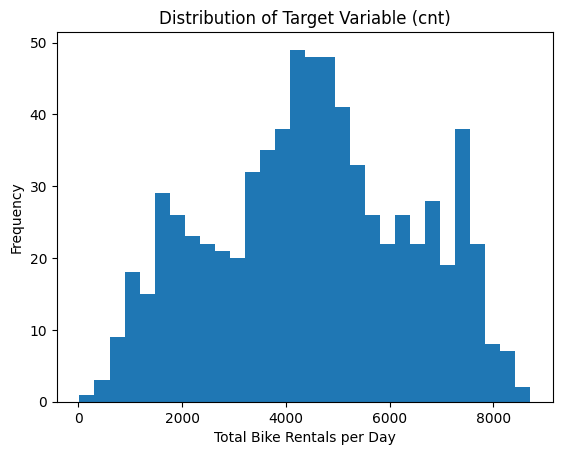

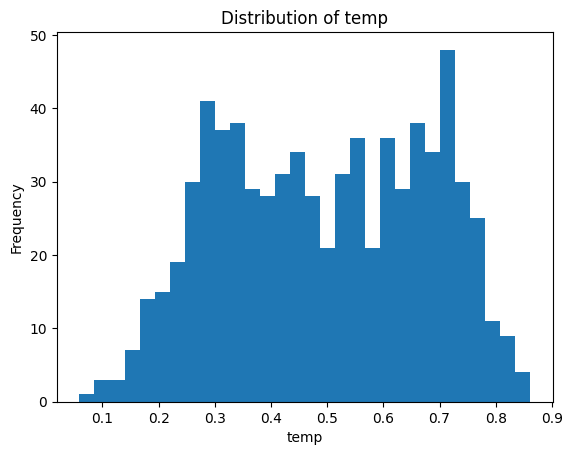

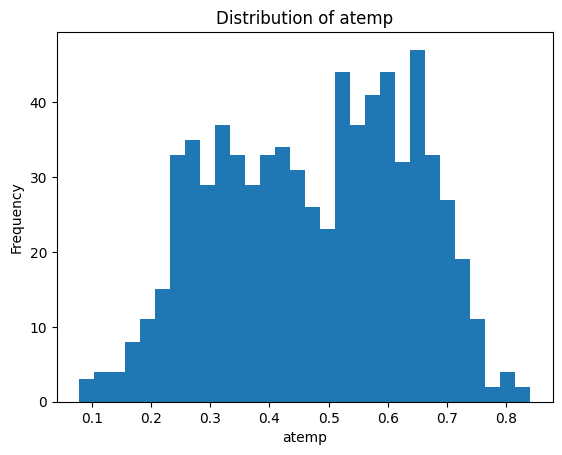

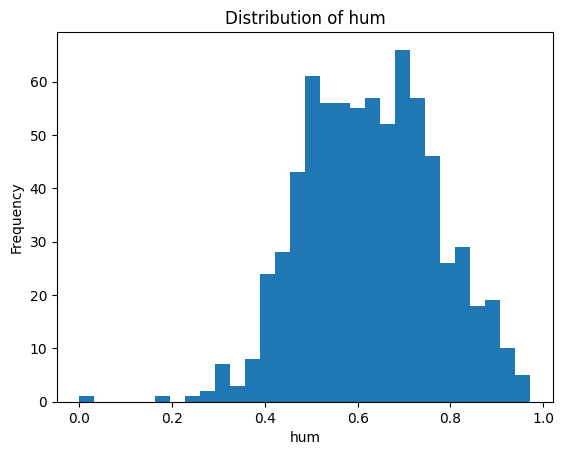

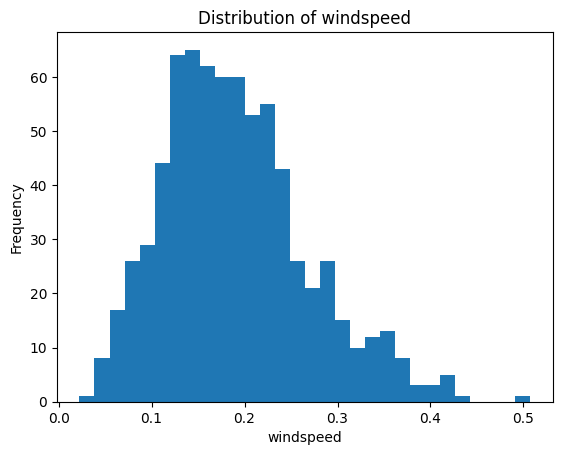

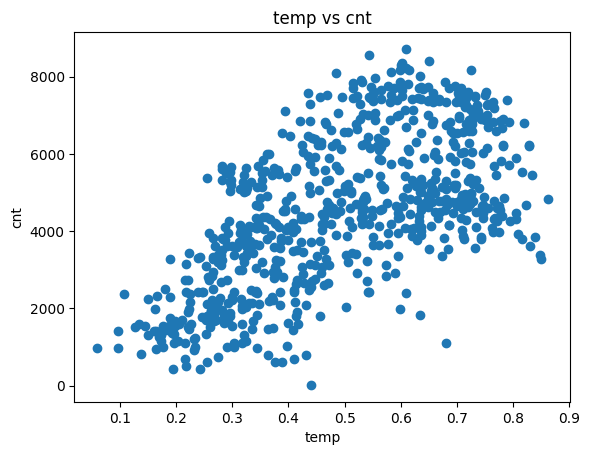

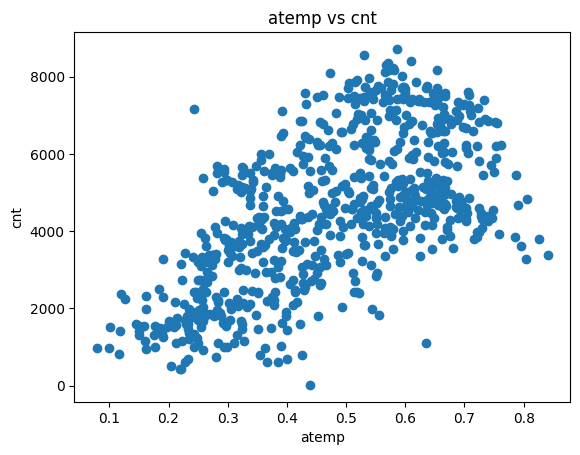

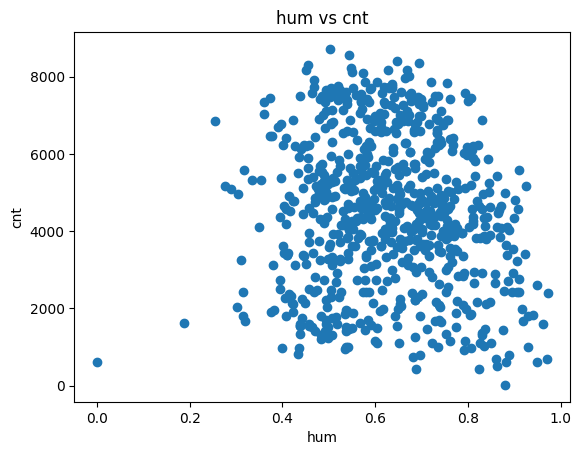

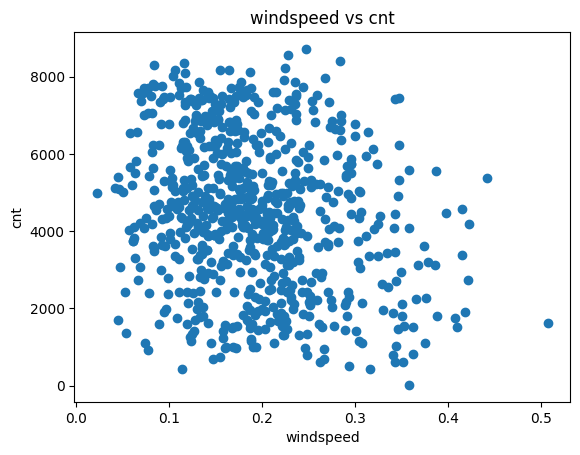


EDA Complete.


In [ ]:
# Reload original data for visualization
df_vis = pd.read_csv(CSV_PATH)

plt.figure()
plt.hist(df_vis['cnt'], bins=30)
plt.title("Distribution of Target Variable (cnt)")
plt.xlabel("Total Bike Rentals per Day")
plt.ylabel("Frequency")
plt.show()

numerical_features = ['temp', 'atemp', 'hum', 'windspeed']

for feature in numerical_features:
    plt.figure()
    plt.hist(df_vis[feature], bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

for feature in numerical_features:
    plt.figure()
    plt.scatter(df_vis[feature], df_vis['cnt'])
    plt.title(f"{feature} vs cnt")
    plt.xlabel(feature)
    plt.ylabel("cnt")
    plt.show()

#2

##2.1

In [3]:
class LinearRegressionClosedForm:
    def __init__(self):
        self.w = None  # model parameters

    def fit(self, X, y):
        # Add bias term
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])

        # Closed-form solution WITHOUT explicit inverse
        # Uses stable least squares (SVD-based internally)
        self.w, _, _, _ = np.linalg.lstsq(X_bias, y, rcond=None)

    def predict(self, X):
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_bias @ self.w

##2.2

In [4]:
# ============================
# 2.2 Train / Test Split
# ============================

def train_test_split(X, y, test_ratio=0.2, seed=66):
    np.random.seed(seed)

    n = X.shape[0]
    indices = np.random.permutation(n)

    test_size = int(n * test_ratio)
    test_idx = indices[:test_size]
    train_idx = indices[test_size:]

    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test


# ----------------------------
# Prepare features and target
# ----------------------------
target_col = "cnt"
X = df_encoded.drop(columns=[target_col]).to_numpy(dtype=float)
y = df_encoded[target_col].to_numpy(dtype=float)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")


NameError: name 'df_encoded' is not defined

##2.3

In [ ]:
# ============================
# 2.3 Evaluation Metric: MSE
# ============================

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


# Train model
model = LinearRegressionClosedForm()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# MSE
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Mean Squared Error (MSE)")
print(f"Training MSE: {train_mse:.4f}")
print(f"Test MSE:   {test_mse:.4f}")


Mean Squared Error (MSE)
Training MSE: 555437.2357
Test MSE:   658413.2054


#3

##3.1

In [ ]:
# ============================
# 3.1 Feature Engineering
# ============================

def add_nonlinear_features(X, feature_names):

    X_new = X.copy()
    new_feature_names = feature_names.copy()

    # Identify continuous features
    continuous = ['temp', 'atemp', 'hum', 'windspeed']
    cont_idx = {f: feature_names.index(f) for f in continuous if f in feature_names}

    # 1) Polynomial features (x^2)
    for f, idx in cont_idx.items():
        X_new = np.hstack([X_new, (X[:, idx] ** 2).reshape(-1, 1)])
        new_feature_names.append(f"{f}^2")

    # 2) Interaction terms
    interactions = [
        ('temp', 'hum'),
        ('temp', 'windspeed')
    ]

    for f1, f2 in interactions:
        if f1 in cont_idx and f2 in cont_idx:
            i, j = cont_idx[f1], cont_idx[f2]
            X_new = np.hstack([X_new, (X[:, i] * X[:, j]).reshape(-1, 1)])
            new_feature_names.append(f"{f1}*{f2}")

    return X_new, new_feature_names


##3.2

In [ ]:
# ============================
# 3.2 Model retraining & analysis
# ============================

# ----- Baseline model (no feature engineering) -----
baseline_model = LinearRegressionClosedForm()
baseline_model.fit(X_train, y_train)

y_train_pred_base = baseline_model.predict(X_train)
baseline_train_mse = mean_squared_error(y_train, y_train_pred_base)


In [ ]:
# ----- Feature engineering on train & test -----
feature_names = df_encoded.drop(columns=['cnt']).columns.tolist()

X_train_fe, fe_feature_names = add_nonlinear_features(X_train, feature_names)
X_test_fe, _ = add_nonlinear_features(X_test, feature_names)

# Retrain model
fe_model = LinearRegressionClosedForm()
fe_model.fit(X_train_fe, y_train)

y_train_pred_fe = fe_model.predict(X_train_fe)
fe_train_mse = mean_squared_error(y_train, y_train_pred_fe)


In [ ]:
print("Task 3: Effect of Non-linear Feature Engineering")
print(f"Training MSE (before feature engineering): {baseline_train_mse:.4f}")
print(f"Training MSE (after  feature engineering): {fe_train_mse:.4f}")
print(f"MSE improvement: {baseline_train_mse - fe_train_mse:.4f}")



Task 3: Effect of Non-linear Feature Engineering
Training MSE (before feature engineering): 560874.4791
Training MSE (after  feature engineering): 466486.0133
MSE improvement: 94388.4658
